In [4]:
import numpy as np
import sympy as sp


In [6]:
alpha, beta, x = sp.symbols('alpha beta x', positive=True)

In [7]:
# 2. Two squared brackets in the integrand
# ------------------------------------------------------------------
expr1 = (alpha*x + beta - sp.sqrt((alpha*x)**2 + beta**2))**2
expr2 = (alpha + beta*x - sp.sqrt(alpha**2 + (beta*x)**2))**2

In [8]:
integrand = expr1 - expr2               # the expression inside { … }
integral   = 3 * sp.integrate(integrand, (x, 0, 1))   # multiply by 3

In [9]:
integral 

3*alpha**3*asinh(beta/alpha)/beta - 2*alpha**3/beta - 4*alpha**2 + 2*alpha**2*sqrt(alpha**2 + beta**2)/beta + alpha*sqrt(alpha**2 + beta**2) + 4*beta**2 - beta*sqrt(alpha**2 + beta**2) - 3*beta**3*asinh(alpha/beta)/alpha + 2*beta**3/alpha - 2*beta**2*sqrt(alpha**2 + beta**2)/alpha

In [10]:
res = sp.simplify(integral)
res

(alpha**3*(3*alpha*asinh(beta/alpha) - 2*alpha + 2*sqrt(alpha**2 + beta**2)) + alpha*beta*(-4*alpha**2 + alpha*sqrt(alpha**2 + beta**2) + 4*beta**2 - beta*sqrt(alpha**2 + beta**2)) + beta**3*(-3*beta*asinh(alpha/beta) + 2*beta - 2*sqrt(alpha**2 + beta**2)))/(alpha*beta)

In [ ]:
delta  = sp.lambdify( (alpha, beta), res, modules='numpy')

In [51]:
integrand1 = expr1
integral1   = 3 * sp.integrate(integrand1, (x, 0, 1)) 
etaXY =  sp.lambdify( (alpha, beta), integral1, modules='numpy')

In [53]:
integrand2 = expr2
integral2   = 3 * sp.integrate(integrand2, (x, 0, 1)) 
etaYX =  sp.lambdify( (alpha, beta), integral2, modules='numpy')

## Plot the surface of Delta(alpha, beta)

In [17]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


<lambdifygenerated-2>:2: RuntimeWarning: divide by zero encountered in divide
  return 2*alpha**2 + 3*alpha*beta - 2*alpha*sqrt(alpha**2 + beta**2) + 6*beta**2 - 3*beta*sqrt(alpha**2 + beta**2) - 3*beta**3*arcsinh(alpha/beta)/alpha + 2*beta**3/alpha - 2*beta**2*sqrt(alpha**2 + beta**2)/alpha
<lambdifygenerated-2>:2: RuntimeWarning: invalid value encountered in divide
  return 2*alpha**2 + 3*alpha*beta - 2*alpha*sqrt(alpha**2 + beta**2) + 6*beta**2 - 3*beta*sqrt(alpha**2 + beta**2) - 3*beta**3*arcsinh(alpha/beta)/alpha + 2*beta**3/alpha - 2*beta**2*sqrt(alpha**2 + beta**2)/alpha
<lambdifygenerated-2>:2: RuntimeWarning: invalid value encountered in multiply
  return 2*alpha**2 + 3*alpha*beta - 2*alpha*sqrt(alpha**2 + beta**2) + 6*beta**2 - 3*beta*sqrt(alpha**2 + beta**2) - 3*beta**3*arcsinh(alpha/beta)/alpha + 2*beta**3/alpha - 2*beta**2*sqrt(alpha**2 + beta**2)/alpha


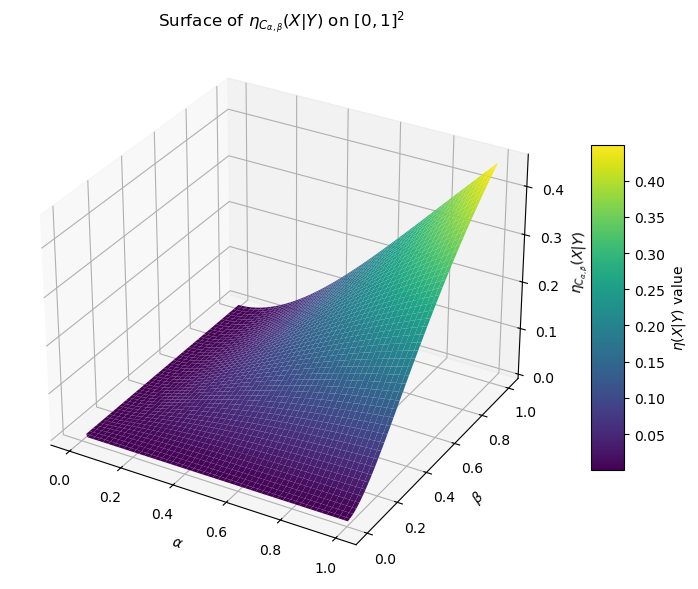

In [52]:
%matplotlib inline
N = 200                              # grid resolution (200×200)
a_vals = np.linspace(0.0, 1.0, N)
b_vals = np.linspace(0.0, 1.0, N)
A, B   = np.meshgrid(a_vals, b_vals) # shape (N,N)

Z = etaXY(A, B)  
fig = plt.figure(figsize=(8,6))
ax  = fig.add_subplot(111, projection='3d')



surf = ax.plot_surface(A, B, Z,
                       cmap='viridis',         # colour map
                       linewidth=0,
                       antialiased=True)

ax.set_xlabel(r'$\alpha$')
ax.set_ylabel(r'$\beta$')
ax.set_zlabel(r'$\eta_{C_{\alpha,\beta}}(X|Y)$')
ax.set_title(r'Surface of $\eta_{C_{\alpha,\beta}}(X|Y)$ on $[0,1]^2$')

fig.colorbar(surf, shrink=0.6, aspect=10, label=r'$\eta(X|Y)$ value')

plt.tight_layout()
plt.show()

<lambdifygenerated-3>:2: RuntimeWarning: divide by zero encountered in divide
  return -3*alpha**3*arcsinh(beta/alpha)/beta + 2*alpha**3/beta + 6*alpha**2 - 2*alpha**2*sqrt(alpha**2 + beta**2)/beta + 3*alpha*beta - 3*alpha*sqrt(alpha**2 + beta**2) + 2*beta**2 - 2*beta*sqrt(alpha**2 + beta**2)
<lambdifygenerated-3>:2: RuntimeWarning: invalid value encountered in divide
  return -3*alpha**3*arcsinh(beta/alpha)/beta + 2*alpha**3/beta + 6*alpha**2 - 2*alpha**2*sqrt(alpha**2 + beta**2)/beta + 3*alpha*beta - 3*alpha*sqrt(alpha**2 + beta**2) + 2*beta**2 - 2*beta*sqrt(alpha**2 + beta**2)
<lambdifygenerated-3>:2: RuntimeWarning: invalid value encountered in multiply
  return -3*alpha**3*arcsinh(beta/alpha)/beta + 2*alpha**3/beta + 6*alpha**2 - 2*alpha**2*sqrt(alpha**2 + beta**2)/beta + 3*alpha*beta - 3*alpha*sqrt(alpha**2 + beta**2) + 2*beta**2 - 2*beta*sqrt(alpha**2 + beta**2)


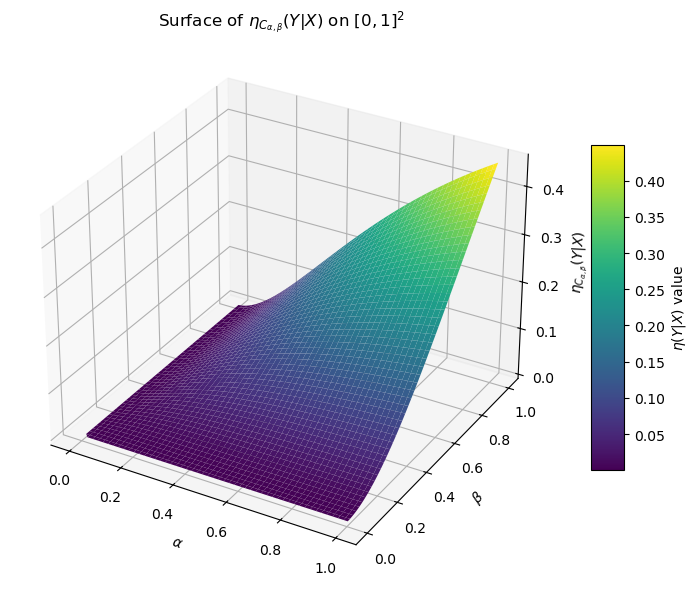

In [54]:
%matplotlib inline
N = 200                              # grid resolution (200×200)
a_vals = np.linspace(0.0, 1.0, N)
b_vals = np.linspace(0.0, 1.0, N)
A, B   = np.meshgrid(a_vals, b_vals) # shape (N,N)

Z = etaYX(A, B)  
fig = plt.figure(figsize=(8,6))
ax  = fig.add_subplot(111, projection='3d')



surf = ax.plot_surface(A, B, Z,
                       cmap='viridis',         # colour map
                       linewidth=0,
                       antialiased=True)

ax.set_xlabel(r'$\alpha$')
ax.set_ylabel(r'$\beta$')
ax.set_zlabel(r'$\eta_{C_{\alpha,\beta}}(Y|X)$')
ax.set_title(r'Surface of $\eta_{C_{\alpha,\beta}}(Y|X)$ on $[0,1]^2$')

fig.colorbar(surf, shrink=0.6, aspect=10, label=r'$\eta(Y|X)$ value')

plt.tight_layout()
plt.show()

<lambdifygenerated-1>:2: RuntimeWarning: divide by zero encountered in divide
  return (alpha**3*(3*alpha*arcsinh(beta/alpha) - 2*alpha + 2*sqrt(alpha**2 + beta**2)) + alpha*beta*(-4*alpha**2 + alpha*sqrt(alpha**2 + beta**2) + 4*beta**2 - beta*sqrt(alpha**2 + beta**2)) + beta**3*(-3*beta*arcsinh(alpha/beta) + 2*beta - 2*sqrt(alpha**2 + beta**2)))/(alpha*beta)
<lambdifygenerated-1>:2: RuntimeWarning: invalid value encountered in divide
  return (alpha**3*(3*alpha*arcsinh(beta/alpha) - 2*alpha + 2*sqrt(alpha**2 + beta**2)) + alpha*beta*(-4*alpha**2 + alpha*sqrt(alpha**2 + beta**2) + 4*beta**2 - beta*sqrt(alpha**2 + beta**2)) + beta**3*(-3*beta*arcsinh(alpha/beta) + 2*beta - 2*sqrt(alpha**2 + beta**2)))/(alpha*beta)
<lambdifygenerated-1>:2: RuntimeWarning: invalid value encountered in multiply
  return (alpha**3*(3*alpha*arcsinh(beta/alpha) - 2*alpha + 2*sqrt(alpha**2 + beta**2)) + alpha*beta*(-4*alpha**2 + alpha*sqrt(alpha**2 + beta**2) + 4*beta**2 - beta*sqrt(alpha**2 + beta**2)) + beta

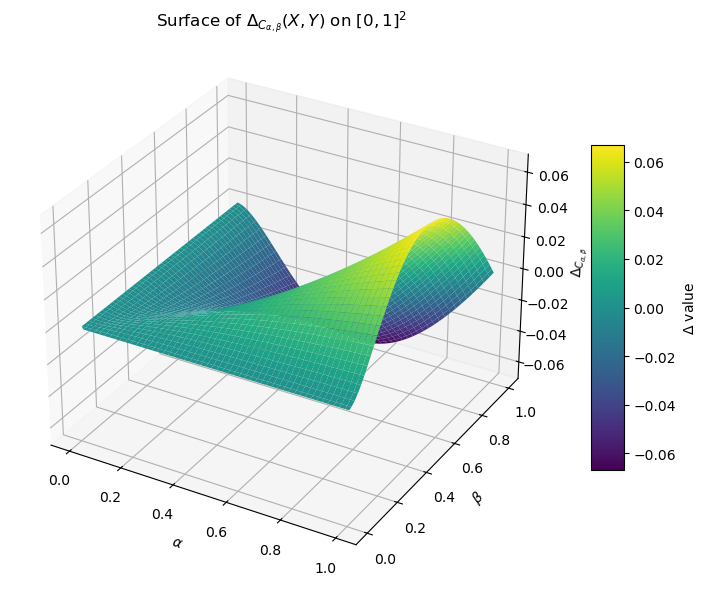

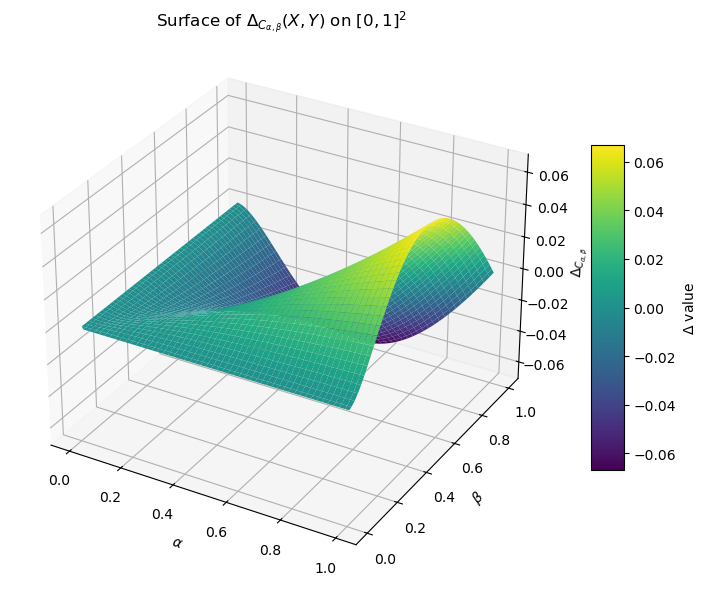

In [46]:
%matplotlib inline
N = 200                              # grid resolution (200×200)
a_vals = np.linspace(0.0, 1.0, N)
b_vals = np.linspace(0.0, 1.0, N)
A, B   = np.meshgrid(a_vals, b_vals) # shape (N,N)

Z = delta(A, B)  
fig = plt.figure(figsize=(8,6))
ax  = fig.add_subplot(111, projection='3d')



surf = ax.plot_surface(A, B, Z,
                       cmap='viridis',         # colour map
                       linewidth=0,
                       antialiased=True)

ax.set_xlabel(r'$\alpha$')
ax.set_ylabel(r'$\beta$')
ax.set_zlabel(r'$\Delta_{C_{\alpha,\beta}}$')
ax.set_title(r'Surface of $\Delta_{C_{\alpha,\beta}}(X,Y)$ on $[0,1]^2$')

fig.colorbar(surf, shrink=0.6, aspect=10, label=r'$\Delta$ value')

plt.tight_layout()
plt.show()


In [47]:
fig.savefig("asymmetrized-gumbel.png") 

In [49]:
print(sp.latex(integral))

\frac{3 \alpha^{3} \operatorname{asinh}{\left(\frac{\beta}{\alpha} \right)}}{\beta} - \frac{2 \alpha^{3}}{\beta} - 4 \alpha^{2} + \frac{2 \alpha^{2} \sqrt{\alpha^{2} + \beta^{2}}}{\beta} + \alpha \sqrt{\alpha^{2} + \beta^{2}} + 4 \beta^{2} - \beta \sqrt{\alpha^{2} + \beta^{2}} - \frac{3 \beta^{3} \operatorname{asinh}{\left(\frac{\alpha}{\beta} \right)}}{\alpha} + \frac{2 \beta^{3}}{\alpha} - \frac{2 \beta^{2} \sqrt{\alpha^{2} + \beta^{2}}}{\alpha}


## find the maximizer of Delta(alpha, beta)

In [50]:
from scipy.optimize import minimize

objective = lambda x: -delta(x[0], x[1])

# Bounds: α, β ∈ [0, 1]
bounds = [(0, 1), (0, 1)]

# Initial guess (e.g., center of square)
x0 = [0.5, 0.5]
res = minimize(objective, x0=x0, bounds=bounds, method='L-BFGS-B')

if res.success:
    alpha_star, beta_star = res.x
    delta_star = delta(alpha_star, beta_star)
    print(f"Max Δ = {delta_star:.6f} at α = {alpha_star:.6f}, β = {beta_star:.6f}")
else:
    print("Optimization failed:", res.message)


Max Δ = 0.068062 at α = 1.000000, β = 0.506984
